In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gmean

In [90]:
result_tket = pd.read_csv('./results/result_uccsd_tket.csv')
result_paulihedral = pd.read_csv('./results/result_uccsd_paulihedral.csv')
result_tetris = pd.read_csv('./results/result_uccsd_tetris.csv')
result_phoenix = pd.read_csv('./results/result_uccsd_phoenix.csv')


In [91]:
num_programs = len(result_tket)
programs = result_tket['program']
num_2q_gates = result_tket['num_2q_gates']
depth_2q = result_tket['depth_2q']

In [92]:
!python display_results_uccsd.py

>>> Num2Q Opt Rate
+----------------+-------+-------------+--------+---------+
| Num2Q Opt Rate |  TKet | Paulihedral | Tetris | Phoenix |
+----------------+-------+-------------+--------+---------+
|    All2all     | 0.315 |    0.284    | 0.537  |  0.187  |
|   All2all O3   | 0.315 |    0.257    | 0.367  |  0.185  |
|     Square     |  0.82 |    0.434    | 0.611  |  0.406  |
|      HHex      | 1.302 |    0.868    | 0.723  |   0.54  |
+----------------+-------+-------------+--------+---------+

>>> Depth2Q Opt Rate
+------------------+-------+-------------+--------+---------+
| Depth2Q Opt Rate |  TKet | Paulihedral | Tetris | Phoenix |
+------------------+-------+-------------+--------+---------+
|     All2all      | 0.289 |    0.291    | 0.533  |   0.16  |
|    All2all O3    | 0.289 |    0.263    | 0.364  |  0.158  |
|      Square      | 0.592 |    0.374    | 0.504  |  0.329  |
|       HHex       | 0.845 |     0.77    | 0.603  |  0.421  |
+------------------+-------+-------------+---

### All2all topology

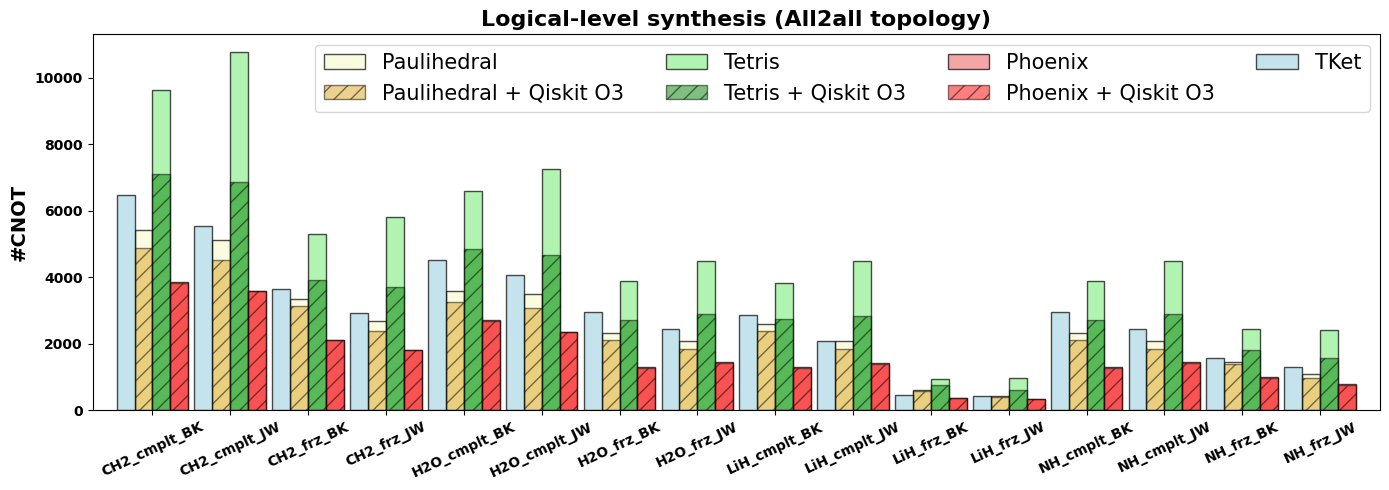

In [69]:
# num_2q_gates
plt.figure(figsize=(14, 5))
width = 0.23
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['num_2q_gates(all2all)'], width=width,
        label='Paulihedral', edgecolor='black', color='lightgoldenrodyellow', alpha=0.7)
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['num_2q_gates(all2all_opt)'], width=width,
        label='Paulihedral + Qiskit O3', edgecolor='black', color='goldenrod', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['num_2q_gates(all2all)'], width=width, label='Tetris',
        edgecolor='black', color='lightgreen', alpha=0.7)
plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['num_2q_gates(all2all_opt)'], width=width,
        label='Tetris + Qiskit O3', edgecolor='black', color='green', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['num_2q_gates(all2all)'], width=width, label='Phoenix',
        edgecolor='black', color='lightcoral', alpha=0.7)
plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['num_2q_gates(all2all_opt)'], width=width,
        label='Phoenix + Qiskit O3', edgecolor='black', color='red', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) - width * 1.5, result_tket['num_2q_gates(all2all)'], width=width, label='TKet',
        edgecolor='black', color='lightblue', alpha=0.7)

plt.xticks(np.arange(num_programs), programs, rotation=25, fontweight='bold')
plt.xlim(width - 1, num_programs - width)
plt.ylabel('#CNOT', fontsize=14, fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(fontsize=15, loc='upper right', ncol=4)
plt.title('Logical-level synthesis (All2all topology)', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('./figures/num_2q_gates_all2all.pdf')
# plt.savefig('./figures/num_2q_gates_all2all.png', dpi=300)
plt.show()

In [70]:
print('optimization rate (TKet)', gmean(result_tket['num_2q_gates(all2all)'] / result_tket['num_2q_gates']).round(4))
print('optimization rate (Paulihedral)',
      gmean(result_paulihedral['num_2q_gates(all2all)'] / result_paulihedral['num_2q_gates']).round(4))
print('optimization rate (Paulihedral + Qiskit O3)',
      gmean(result_paulihedral['num_2q_gates(all2all_opt)'] / result_paulihedral['num_2q_gates']).round(4))
print('optimization rate (Tetris)',
      gmean(result_tetris['num_2q_gates(all2all)'] / result_tetris['num_2q_gates']).round(4))
print('optimization rate (Tetris + Qiskit O3)',
      gmean(result_tetris['num_2q_gates(all2all_opt)'] / result_tetris['num_2q_gates']).round(4))
print('optimiozation rate (Phoenix)',
      gmean(result_phoenix['num_2q_gates(all2all)'] / result_phoenix['num_2q_gates']).round(4))
print('optimization rate (Phoenix + Qiskit O3)',
      gmean(result_phoenix['num_2q_gates(all2all_opt)'] / result_phoenix['num_2q_gates']).round(4))

optimization rate (TKet) 0.3148
optimization rate (Paulihedral) 0.2841
optimization rate (Paulihedral + Qiskit O3) 0.2572
optimization rate (Tetris) 0.5366
optimization rate (Tetris + Qiskit O3) 0.3673
optimiozation rate (Phoenix) 0.1868
optimization rate (Phoenix + Qiskit O3) 0.1847


In [71]:
print('Paulihedral optimization rate improvement v.s. No Qiskit O3: {:.2f}%'.format(
    100 * (gmean(1 - result_paulihedral['num_2q_gates(all2all_opt)'] / result_paulihedral['num_2q_gates(all2all)']))))
print('Tetris optimization rate improvement v.s. No Qiskit O3: {:.2f}%'.format(
    100 * (gmean(1 - result_tetris['num_2q_gates(all2all_opt)'] / result_tetris['num_2q_gates(all2all)']))))
print('Phoenix optimization rate improvement v.s. No Qiskit O3: {:.2f}%'.format(
    100 * (gmean(1 - result_phoenix['num_2q_gates(all2all_opt)'] / result_phoenix['num_2q_gates(all2all)']))))

Paulihedral optimization rate improvement v.s. No Qiskit O3: 8.54%
Tetris optimization rate improvement v.s. No Qiskit O3: 30.94%
Phoenix optimization rate improvement v.s. No Qiskit O3: 0.94%


In [72]:
# print('Paulihedral optimization rate improvement v.s. No Qiskit O3: {:.4f}'.format( geometric_mean(1 - result_paulihedral['num_2q_gates(all2all_opt)'] / result_paulihedral['num_2q_gates(all2all)'])))
# print('Tetris optimization rate improvement v.s. No Qiskit O3: {:.4f}'.format(geometric_mean(1 - result_tetris['num_2q_gates(all2all_opt)'] / result_tetris['num_2q_gates(all2all)'])))
# print('Phoenix optimization rate improvement v.s. No Qiskit O3: {:.4f}'.format(geometric_mean(1 - result_phoenix['num_2q_gates(all2all_opt)'] / result_phoenix['num_2q_gates(all2all)'])))

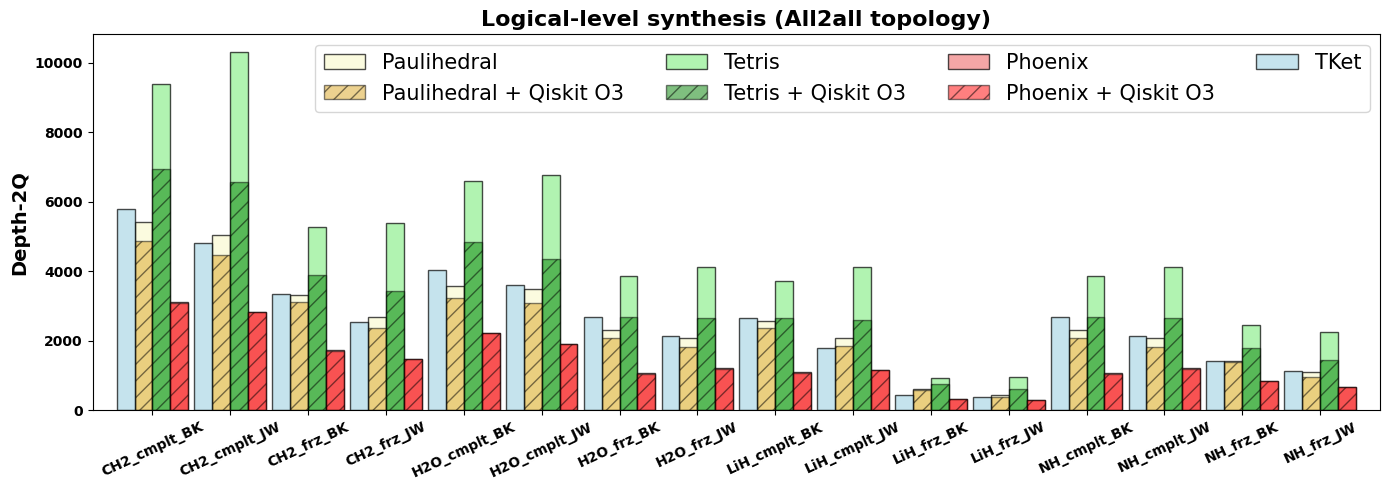

In [73]:
# depth_2q
plt.figure(figsize=(14, 5))
width = 0.23
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['depth_2q(all2all)'], width=width,
        label='Paulihedral', edgecolor='black', color='lightgoldenrodyellow', alpha=0.7)
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['depth_2q(all2all_opt)'], width=width,
        label='Paulihedral + Qiskit O3', edgecolor='black', color='goldenrod', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['depth_2q(all2all)'], width=width, label='Tetris',
        edgecolor='black', color='lightgreen', alpha=0.7)
plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['depth_2q(all2all_opt)'], width=width,
        label='Tetris + Qiskit O3', edgecolor='black', color='green', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['depth_2q(all2all)'], width=width, label='Phoenix',
        edgecolor='black', color='lightcoral', alpha=0.7)
plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['depth_2q(all2all_opt)'], width=width,
        label='Phoenix + Qiskit O3', edgecolor='black', color='red', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) - width * 1.5, result_tket['depth_2q(all2all)'], width=width, label='TKet',
        edgecolor='black', color='lightblue', alpha=0.7)

plt.xticks(np.arange(num_programs), programs, rotation=25, fontweight='bold')
plt.xlim(width - 1, num_programs - width)
plt.ylabel('Depth-2Q', fontsize=14, fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(fontsize=15, loc='upper right', ncol=4)
plt.title('Logical-level synthesis (All2all topology)', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('./figures/depth_2q_all2all.pdf')
# plt.savefig('./figures/depth_2q_all2all.png', dpi=300)

plt.show()

In [74]:
print('optimization rate (TKet)', gmean(result_tket['depth_2q(all2all)'] / result_tket['depth_2q']).round(4))
print('optimization rate (Paulihedral)',
      gmean(result_paulihedral['depth_2q(all2all)'] / result_paulihedral['depth_2q']).round(4))
print('optimization rate (Paulihedral + Qiskit O3)',
      gmean(result_paulihedral['depth_2q(all2all_opt)'] / result_paulihedral['depth_2q']).round(4))
print('optimization rate (Tetris)', gmean(result_tetris['depth_2q(all2all)'] / result_tetris['depth_2q']).round(4))
print('optimization rate (Tetris + Qiskit O3)',
      gmean(result_tetris['depth_2q(all2all_opt)'] / result_tetris['depth_2q']).round(4))
print('optimiozation rate (Phoenix)', gmean(result_phoenix['depth_2q(all2all)'] / result_phoenix['depth_2q']).round(4))
print('optimization rate (Phoenix + Qiskit O3)',
      gmean(result_phoenix['depth_2q(all2all_opt)'] / result_phoenix['depth_2q']).round(4))

optimization rate (TKet) 0.2887
optimization rate (Paulihedral) 0.2907
optimization rate (Paulihedral + Qiskit O3) 0.263
optimization rate (Tetris) 0.5326
optimization rate (Tetris + Qiskit O3) 0.3637
optimiozation rate (Phoenix) 0.1602
optimization rate (Phoenix + Qiskit O3) 0.1584


In [75]:
print('Paulihedral optimization rate improvement v.s. No Qiskit O3: {:.2f}%'.format(
    100 * (gmean(1 - result_paulihedral['depth_2q(all2all_opt)'] / result_paulihedral['depth_2q(all2all)']))))
print('Tetris optimization rate improvement v.s. No Qiskit O3: {:.2f}%'.format(
    100 * (gmean(1 - result_tetris['depth_2q(all2all_opt)'] / result_tetris['depth_2q(all2all)']))))
print('Phoenix optimization rate improvement v.s. No Qiskit O3: {:.2f}%'.format(
    100 * (gmean(1 - result_phoenix['depth_2q(all2all_opt)'] / result_phoenix['depth_2q(all2all)']))))

Paulihedral optimization rate improvement v.s. No Qiskit O3: 8.60%
Tetris optimization rate improvement v.s. No Qiskit O3: 31.08%
Phoenix optimization rate improvement v.s. No Qiskit O3: 0.96%


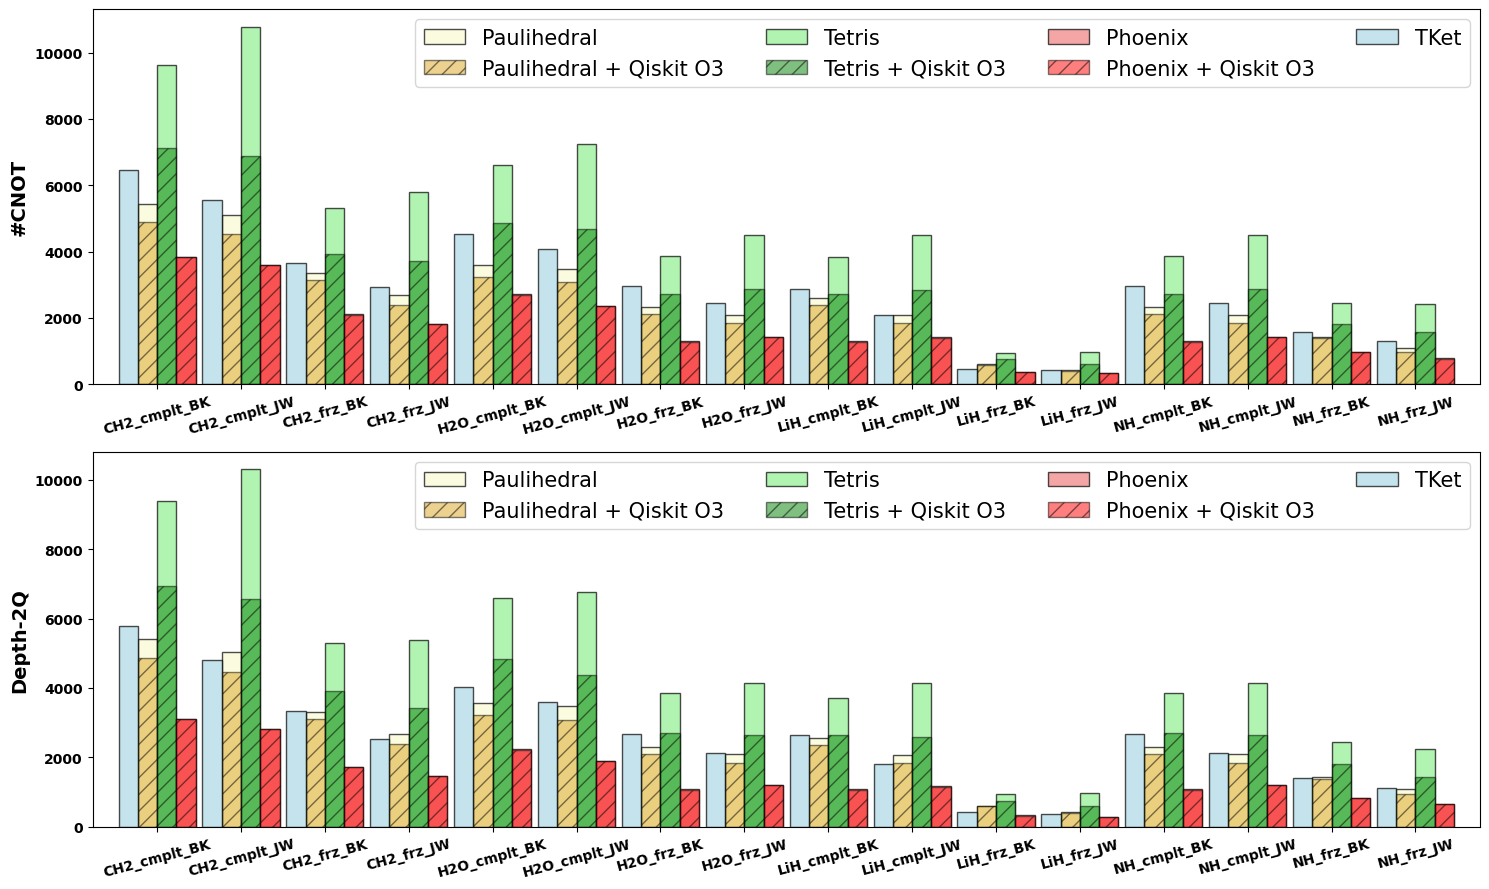

In [76]:
# 画在同一张图
plt.figure(figsize=(15, 9))

# num_2q_gates
plt.subplot(2, 1, 1)
width = 0.23
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['num_2q_gates(all2all)'], width=width,
        label='Paulihedral', edgecolor='black', color='lightgoldenrodyellow', alpha=0.7)
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['num_2q_gates(all2all_opt)'], width=width,
        label='Paulihedral + Qiskit O3', edgecolor='black', color='goldenrod', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['num_2q_gates(all2all)'], width=width, label='Tetris',
        edgecolor='black', color='lightgreen', alpha=0.7)
plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['num_2q_gates(all2all_opt)'], width=width,
        label='Tetris + Qiskit O3', edgecolor='black', color='green', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['num_2q_gates(all2all)'], width=width, label='Phoenix',
        edgecolor='black', color='lightcoral', alpha=0.7)
plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['num_2q_gates(all2all_opt)'], width=width,
        label='Phoenix + Qiskit O3', edgecolor='black', color='red', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) - width * 1.5, result_tket['num_2q_gates(all2all)'], width=width, label='TKet',
        edgecolor='black', color='lightblue', alpha=0.7)

plt.xticks(np.arange(num_programs), programs, rotation=15, fontweight='bold')
# plt.xticks([])
plt.xlim(width - 1, num_programs - width)
plt.ylabel('#CNOT', fontsize=14, fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(fontsize=15, loc='upper right', ncol=4)
# plt.title('Logical-level primitive (All2all topology)', fontsize=16, fontweight='bold')


# depth_2q
plt.subplot(2, 1, 2)
width = 0.23
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['depth_2q(all2all)'], width=width,
        label='Paulihedral', edgecolor='black', color='lightgoldenrodyellow', alpha=0.7)
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['depth_2q(all2all_opt)'], width=width,
        label='Paulihedral + Qiskit O3', edgecolor='black', color='goldenrod', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['depth_2q(all2all)'], width=width, label='Tetris',
        edgecolor='black', color='lightgreen', alpha=0.7)
plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['depth_2q(all2all_opt)'], width=width,
        label='Tetris + Qiskit O3', edgecolor='black', color='green', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['depth_2q(all2all)'], width=width, label='Phoenix',
        edgecolor='black', color='lightcoral', alpha=0.7)
plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['depth_2q(all2all_opt)'], width=width,
        label='Phoenix + Qiskit O3', edgecolor='black', color='red', alpha=0.5, hatch='//')

plt.bar(np.arange(num_programs) - width * 1.5, result_tket['depth_2q(all2all)'], width=width, label='TKet',
        edgecolor='black', color='lightblue', alpha=0.7)

plt.xticks(np.arange(num_programs), programs, rotation=15, fontweight='bold')
plt.xlim(width - 1, num_programs - width)
plt.ylabel('Depth-2Q', fontsize=14, fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(fontsize=15, loc='upper right', ncol=4)

plt.tight_layout()
plt.savefig('./figures/uccsd_all2all.pdf')
plt.show()

### Manhattan

In [77]:
# calculate rouring overhead (manhattan v.s. all2all)

routing_overhead = {
    'paulihedral': result_paulihedral['num_2q_gates(hhex)'] / result_paulihedral['num_2q_gates(all2all_opt)'],
    'tetris': result_tetris['num_2q_gates(hhex)'] / result_tetris['num_2q_gates(all2all_opt)'],
    'phoenix': result_phoenix['num_2q_gates(hhex)'] / result_phoenix['num_2q_gates(all2all_opt)']
}

In [78]:
routing_overhead['phoenix']

0     3.479352
1     3.229376
2     3.036260
3     2.941860
4     3.134823
5     3.137887
6     2.744866
7     2.910877
8     2.811719
9     3.024268
10    2.576177
11    2.608696
12    2.822275
13    2.876491
14    2.814928
15    2.794003
dtype: float64

In [79]:
gmean(routing_overhead['paulihedral']).round(4), gmean(routing_overhead['tetris']).round(4), gmean(
    routing_overhead['phoenix']).round(4)

(3.3735, 1.9685, 2.9255)

In [80]:
# 1 - gmean(result_phoenix['num_2q_gates(manhattan)'] / result_paulihedral['num_2q_gates(manhattan)']), 1 - gmean(result_phoenix['num_2q_gates(manhattan)'] / result_tetris['num_2q_gates(manhattan)'])

In [81]:
gmean(1 - result_phoenix['num_2q_gates(hhex)'] / result_paulihedral['num_2q_gates(hhex)']), gmean(
    1 - result_phoenix['num_2q_gates(hhex)'] / result_tetris['num_2q_gates(hhex)'])


(0.35619831244515426, 0.22455495961744548)

In [82]:
gmean(1 - result_phoenix['depth_2q(hhex)'] / result_paulihedral['depth_2q(hhex)']), gmean(
    1 - result_phoenix['depth_2q(hhex)'] / result_tetris['depth_2q(hhex)'])


(0.43656299276670146, 0.29274753275843457)

optimization rate (Paulihedral) (TKet as baseline) 0.6664
optimization rate (Tetris) (TKet as baseline) 0.5552
optimization rate (Phoenix) (TKet as baseline) 0.4151


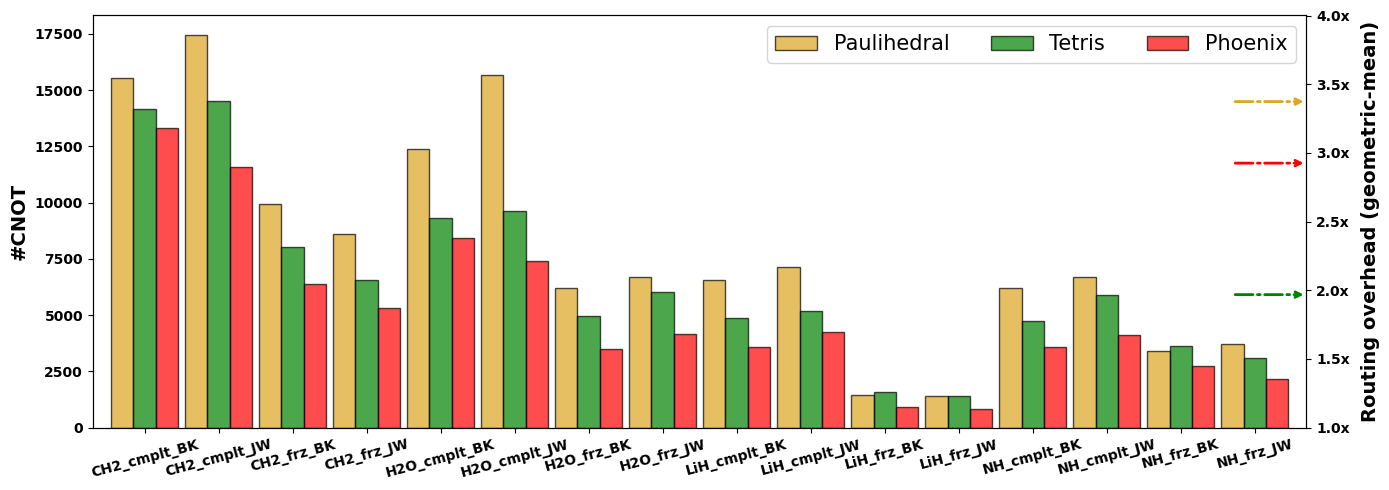

In [83]:
# num_2q_gates
plt.figure(figsize=(14, 5))
width = 0.3
# plt.bar(np.arange(num_programs) - width * 1.5, result_tket['num_2q_gates(hhex)'], width=width, label='TKet', edgecolor='gray')

plt.bar(np.arange(num_programs) - width, result_paulihedral['num_2q_gates(hhex)'], width=width,
        label='Paulihedral', edgecolor='black', color='goldenrod', alpha=0.7)
plt.bar(np.arange(num_programs), result_tetris['num_2q_gates(hhex)'], width=width, label='Tetris',
        edgecolor='black', color='green', alpha=0.7)
plt.bar(np.arange(num_programs) + width, result_phoenix['num_2q_gates(hhex)'], width=width, label='Phoenix',
        edgecolor='black', color='red', alpha=0.7)

plt.xticks(np.arange(num_programs), programs, rotation=15, fontweight='bold')
plt.xlim(width - 1, num_programs - width)
plt.ylabel('#CNOT', fontsize=14, fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(fontsize=15, loc='upper right', ncol=3)

ax = plt.twinx()

print('optimization rate (Paulihedral) (TKet as baseline)',
      gmean(result_paulihedral['num_2q_gates(hhex)'] / result_tket['num_2q_gates(hhex)']).round(4))
print('optimization rate (Tetris) (TKet as baseline)',
      gmean(result_tetris['num_2q_gates(hhex)'] / result_tket['num_2q_gates(hhex)']).round(4))
print('optimization rate (Phoenix) (TKet as baseline)',
      gmean(result_phoenix['num_2q_gates(hhex)'] / result_tket['num_2q_gates(hhex)']).round(4))

ax.annotate('',
            xy=(num_programs - 0.3, gmean(routing_overhead['paulihedral'])),
            xytext=(num_programs - 1.3, gmean(routing_overhead['paulihedral'])),
            arrowprops=dict(arrowstyle='->', color='goldenrod', lw=2, ls='-.'))
ax.annotate('',
            xy=(num_programs - 0.3, gmean(routing_overhead['tetris'])),
            xytext=(num_programs - 1.3, gmean(routing_overhead['tetris'])),
            arrowprops=dict(arrowstyle='->', color='green', lw=2, ls='-.'))
ax.annotate('',
            xy=(num_programs - 0.3, gmean(routing_overhead['phoenix'])),
            xytext=(num_programs - 1.3, gmean(routing_overhead['phoenix'])),
            arrowprops=dict(arrowstyle='->', color='red', lw=2, ls='-.'))


def format_func(value, tick_number):
    return f'{value:.1f}x'


ax.yaxis.set_major_formatter(plt.FuncFormatter(format_func))
ax.tick_params(axis='y', which='major')
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.set_ylim(1.0, 4.0)
ax.set_ylabel('Routing overhead (geometric-mean)', fontsize=14, fontweight='bold', labelpad=8)

# plt.title('Hardware-aware primitive (Manhattan)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./figures/uccsd_manhattan.pdf')

plt.show()

In this version of Phoenix compiler, we perform Qiskit's `CommutativeInverseCancellation` pass on the self-defined Clifford2Q + CNOt + U3 circuits. It effectively optimizes the logical circuit, but the final hardware circuit after Qiskit O3 mapping almost holds the same. That means this instead will increase routing overhead. This implies there are still large co-optimization space to be exploited.

In [84]:
print('optimization rate (Paulihedral) (TKet as baseline)',
      gmean(result_paulihedral['num_2q_gates(hhex)'] / result_tket['num_2q_gates(hhex)']).round(4))
print('optimization rate (Tetris) (TKet as baseline)',
      gmean(result_tetris['num_2q_gates(hhex)'] / result_tket['num_2q_gates(hhex)']).round(4))
print('optimization rate (Phoenix) (TKet as baseline)',
      gmean(result_phoenix['num_2q_gates(hhex)'] / result_tket['num_2q_gates(hhex)']).round(4))

optimization rate (Paulihedral) (TKet as baseline) 0.6664
optimization rate (Tetris) (TKet as baseline) 0.5552
optimization rate (Phoenix) (TKet as baseline) 0.4151


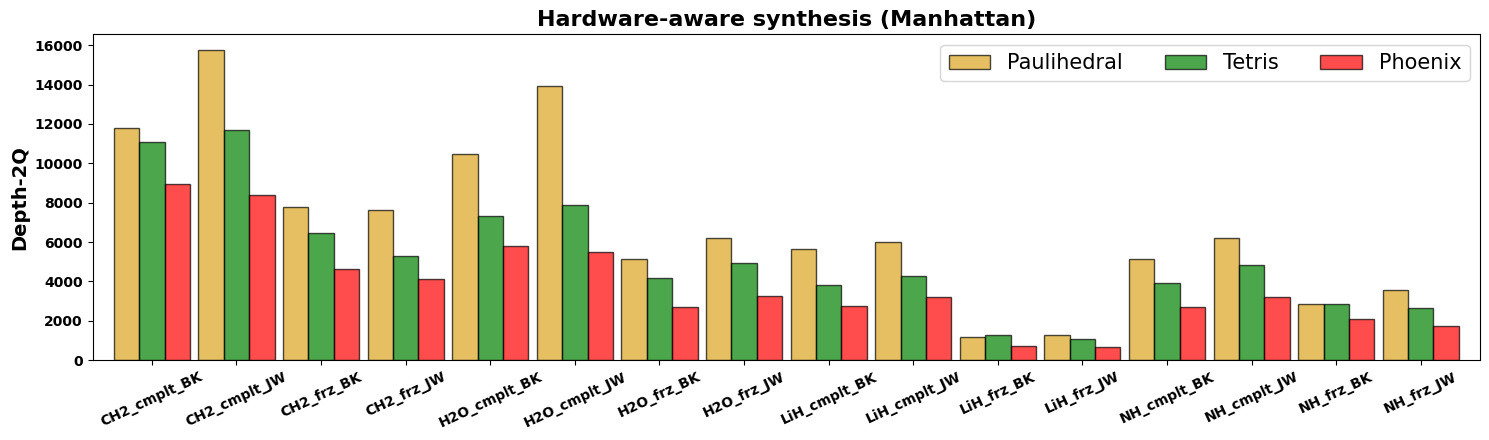

In [85]:
# depth_2q
plt.figure(figsize=(15, 4.5))
width = 0.3
# plt.bar(np.arange(num_programs) - width * 1.5, result_tket['depth_2q(hhex)'], width=width, label='TKet')
plt.bar(np.arange(num_programs) - width, result_paulihedral['depth_2q(hhex)'], width=width, label='Paulihedral',
        edgecolor='black', color='goldenrod', alpha=0.7)
plt.bar(np.arange(num_programs), result_tetris['depth_2q(hhex)'], width=width, label='Tetris', edgecolor='black',
        color='green', alpha=0.7)
plt.bar(np.arange(num_programs) + width, result_phoenix['depth_2q(hhex)'], width=width, label='Phoenix',
        edgecolor='black', color='red', alpha=0.7)

plt.xticks(np.arange(num_programs), programs, rotation=25, fontweight='bold')
plt.xlim(width - 1, num_programs - width)
plt.ylabel('Depth-2Q', fontsize=14, fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(fontsize=15, loc='upper right', ncol=3)
plt.title('Hardware-aware synthesis (Manhattan)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [86]:
print('optimization rate (Paulihedral) (TKet as baseline)',
      gmean(result_paulihedral['depth_2q(hhex)'] / result_tket['depth_2q(hhex)']).round(4))
print('optimization rate (Tetris) (TKet as baseline)',
      gmean(result_tetris['depth_2q(hhex)'] / result_tket['depth_2q(hhex)']).round(4))
print('optimization rate (Phoenix) (TKet as baseline)',
      gmean(result_phoenix['depth_2q(hhex)'] / result_tket['depth_2q(hhex)']).round(4))

optimization rate (Paulihedral) (TKet as baseline) 0.9112
optimization rate (Tetris) (TKet as baseline) 0.7133
optimization rate (Phoenix) (TKet as baseline) 0.4979


### Sycamore

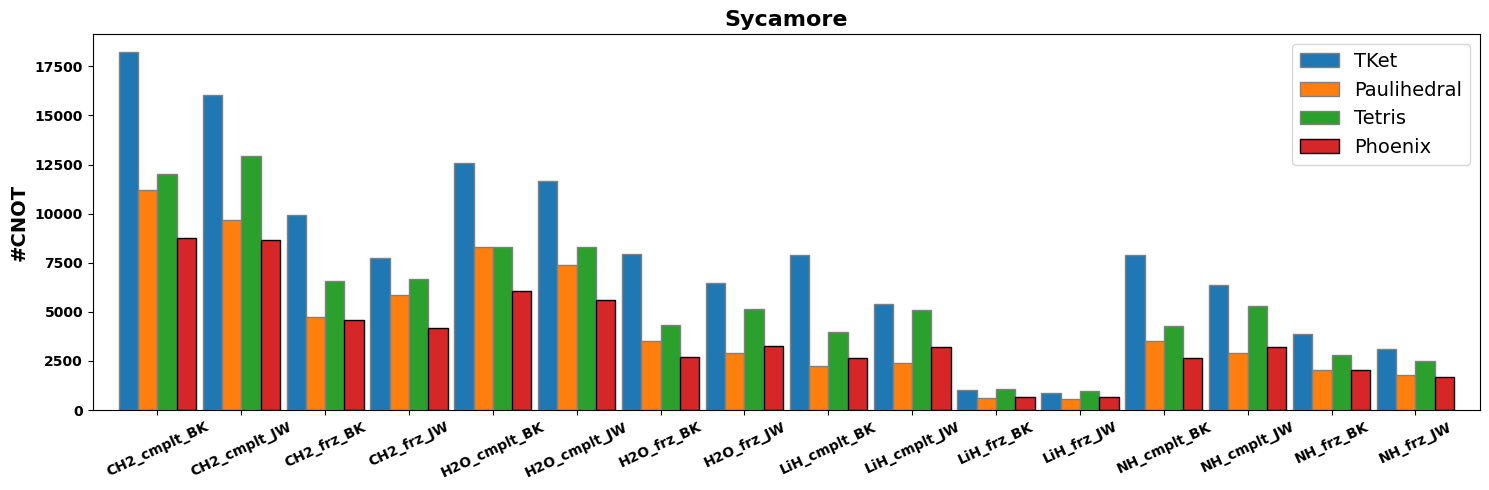

In [87]:
# num_2q_gates
plt.figure(figsize=(15, 5))
width = 0.23
plt.bar(np.arange(num_programs) - width * 1.5, result_tket['num_2q_gates(square)'], width=width, label='TKet',
        edgecolor='gray')
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['num_2q_gates(square)'], width=width,
        label='Paulihedral', edgecolor='gray')
plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['num_2q_gates(square)'], width=width, label='Tetris',
        edgecolor='gray')
plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['num_2q_gates(square)'], width=width, label='Phoenix',
        edgecolor='black')
plt.xticks(np.arange(num_programs), programs, rotation=25, fontweight='bold')
plt.xlim(width - 1, num_programs - width)
plt.ylabel('#CNOT', fontsize=14, fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(fontsize=14)
plt.title('Sycamore', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

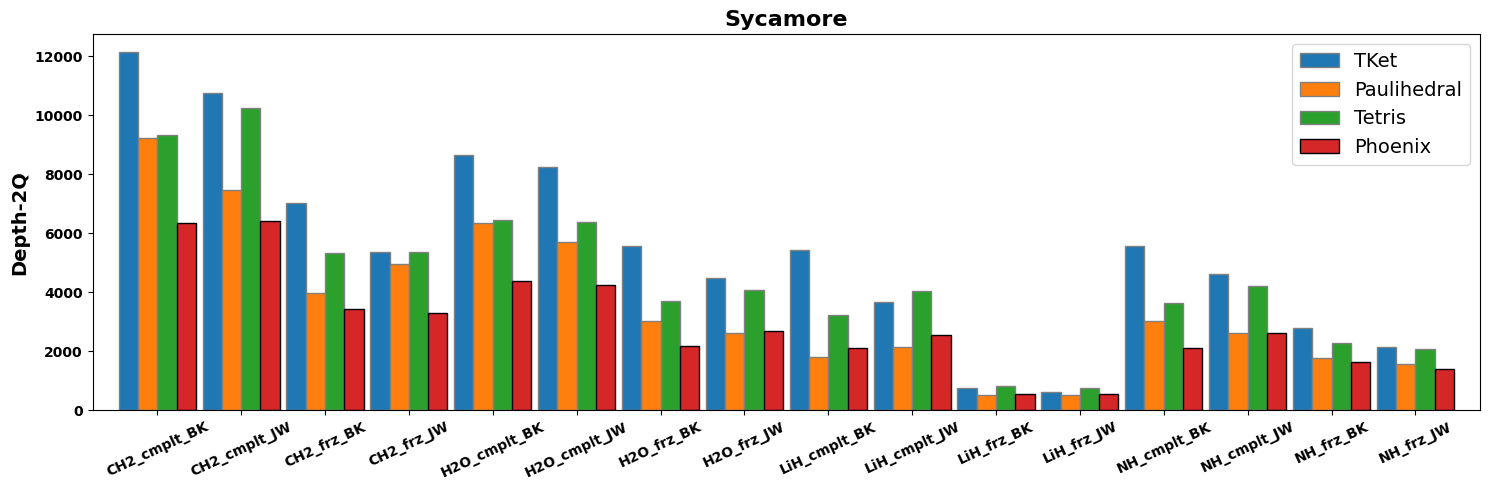

In [88]:
# depth_2q
plt.figure(figsize=(15, 5))
width = 0.23
plt.bar(np.arange(num_programs) - width * 1.5, result_tket['depth_2q(square)'], width=width, label='TKet', edgecolor='gray')
plt.bar(np.arange(num_programs) - width * 0.5, result_paulihedral['depth_2q(square)'], width=width,
        label='Paulihedral', edgecolor='gray')
plt.bar(np.arange(num_programs) + width * 0.5, result_tetris['depth_2q(square)'], width=width, label='Tetris', edgecolor='gray')
plt.bar(np.arange(num_programs) + width * 1.5, result_phoenix['depth_2q(square)'], width=width, label='Phoenix', edgecolor='black')
plt.xticks(np.arange(num_programs), programs, rotation=25, fontweight='bold')
plt.xlim(width - 1, num_programs - width)
plt.ylabel('Depth-2Q', fontsize=14, fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(fontsize=14)
plt.title('Sycamore', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### SU(4) ISA

In [95]:
import sys
sys.path.append('../..')
import bqskit
from bqskit.compiler import Compiler
from bqskit.passes import QuickPartitioner
from phoenix import Circuit, gates
from phoenix.utils.ops import is_tensor_prod

import os
from tqdm import tqdm

In [96]:
def su4_circ_stats(qasm_fname):
    """Statistic of #2Q and Depth-2Q of SU(4)-based circuit."""
    circ = bqskit.Circuit.from_file(qasm_fname)
    blocks = list(bqskit_compiler.compile(circ, workflow))
    circ_su4 = Circuit(
        [gates.X.on(blk.location[0], blk.location[1]) for blk in blocks if blk.get_unitary().numpy.shape == (4, 4) and not is_tensor_prod(blk.get_unitary().numpy)])
    return circ_su4.num_gates, circ_su4.depth

bqskit_compiler = Compiler()
workflow = QuickPartitioner(2)

selected_benchmarks = [
    'CH2_cmplt_BK',
    'CH2_cmplt_JW',
    'CH2_frz_BK',
    'CH2_frz_JW',
    'H2O_cmplt_BK',
    'H2O_cmplt_JW',
    'H2O_frz_BK',
    'H2O_frz_JW',
    'LiH_cmplt_BK',
    'LiH_cmplt_JW',
    'LiH_frz_BK',
    'LiH_frz_JW',
    'NH_cmplt_BK',
    'NH_cmplt_JW',
    'NH_frz_BK',
    'NH_frz_JW'
]

OUTPUT_DPATH = './output_uccsd/'

result = pd.DataFrame(columns=['program', 'num_su4(tket)', 'depth_su4(tket)',
                               'num_su4(paulihedral)', 'depth_su4(paulihedral)',
                               'num_su4(tetris)', 'depth_su4(tetris)',
                               'num_su4(phoenix)', 'depth_su4(phoenix)'])
result['program'] = selected_benchmarks

for compiler in ['tket', 'paulihedral', 'tetris', 'phoenix']:
    num_su4_list = []
    depth_su4_list = []
    output_dpath = os.path.join(OUTPUT_DPATH, compiler, 'all2all_opt')
    print(f'Processing {output_dpath}...')
    for program_name in tqdm(selected_benchmarks):
        fname = os.path.join(output_dpath, program_name + '_sto3g' + '.qasm')
        num_su4, depth_su4 = su4_circ_stats(fname)
        num_su4_list.append(num_su4)
        depth_su4_list.append(depth_su4)

    result[f'num_su4({compiler})'] = num_su4_list
    result[f'depth_su4({compiler})'] = depth_su4_list

bqskit_compiler.close()

Processing ./output_uccsd/tket/all2all_opt...


100%|██████████| 16/16 [00:35<00:00,  2.23s/it]


Processing ./output_uccsd/paulihedral/all2all_opt...


100%|██████████| 16/16 [00:29<00:00,  1.84s/it]


Processing ./output_uccsd/tetris/all2all_opt...


100%|██████████| 16/16 [00:42<00:00,  2.63s/it]


Processing ./output_uccsd/phoenix/all2all_opt...


100%|██████████| 16/16 [00:23<00:00,  1.48s/it]


In [99]:
bqskit_compiler = Compiler()
workflow = QuickPartitioner(2)

result_hhex = pd.DataFrame(columns=['program', 'num_su4(tket)', 'depth_su4(tket)',
                               'num_su4(paulihedral)', 'depth_su4(paulihedral)',
                               'num_su4(tetris)', 'depth_su4(tetris)',
                               'num_su4(phoenix)', 'depth_su4(phoenix)'])
result_hhex['program'] = selected_benchmarks

for compiler in ['tket', 'paulihedral', 'tetris', 'phoenix']:
    num_su4_list = []
    depth_su4_list = []
    output_dpath = os.path.join(OUTPUT_DPATH, compiler, 'hhex')
    print(f'Processing {output_dpath}...')
    for program_name in tqdm(selected_benchmarks):
        fname = os.path.join(output_dpath, program_name + '_sto3g' + '.qasm')
        num_su4, depth_su4 = su4_circ_stats(fname)
        num_su4_list.append(num_su4)
        depth_su4_list.append(depth_su4)

    result_hhex[f'num_su4({compiler})'] = num_su4_list
    result_hhex[f'depth_su4({compiler})'] = depth_su4_list

bqskit_compiler.close()

Processing ./output_uccsd/tket/hhex...


100%|██████████| 16/16 [01:29<00:00,  5.62s/it]


Processing ./output_uccsd/paulihedral/hhex...


100%|██████████| 16/16 [01:27<00:00,  5.47s/it]


Processing ./output_uccsd/tetris/hhex...


100%|██████████| 16/16 [01:06<00:00,  4.18s/it]


Processing ./output_uccsd/phoenix/hhex...


100%|██████████| 16/16 [00:44<00:00,  2.75s/it]


In [100]:
# All2all

print('number of SU(4) gates')

print('reduction rates v.s. tket, {:.2f}%'.format(gmean(result['num_su4(phoenix)'] / result['num_su4(tket)']) * 100))
print('reduction rates v.s. paulihedral: {:.2f}%'.format(gmean(result['num_su4(phoenix)'] / result['num_su4(paulihedral)']) * 100))
print('reduction rates v.s. tetris: {:.2f}%'.format(gmean(result['num_su4(phoenix)'] / result['num_su4(tetris)']) * 100))

print('depth of SU(4) gates') 
print('reduction rates v.s. tket: {:.2f}%'.format(gmean(result['depth_su4(phoenix)'] / result['depth_su4(tket)']) * 100))
print('reduction rates v.s. paulihedral: {:.2f}%'.format(gmean(result['depth_su4(phoenix)'] / result['depth_su4(paulihedral)']) * 100))
print('reduction rates v.s. tetris: {:.2f}%'.format(gmean(result['depth_su4(phoenix)'] / result['depth_su4(tetris)']) * 100))

number of SU(4) gates
reduction rates v.s. tket, 55.11%
reduction rates v.s. paulihedral: 71.15%
reduction rates v.s. tetris: 53.24%
depth of SU(4) gates
reduction rates v.s. tket: 51.13%
reduction rates v.s. paulihedral: 59.28%
reduction rates v.s. tetris: 45.96%


In [101]:
# HHex

print('number of SU(4) gates')

print('reduction rates v.s. tket, {:.2f}%'.format(gmean(result_hhex['num_su4(phoenix)'] / result_hhex['num_su4(tket)']) * 100))
print('reduction rates v.s. paulihedral: {:.2f}%'.format(gmean(result_hhex['num_su4(phoenix)'] / result_hhex['num_su4(paulihedral)']) * 100))
print('reduction rates v.s. tetris: {:.2f}%'.format(gmean(result_hhex['num_su4(phoenix)'] / result_hhex['num_su4(tetris)']) * 100))

print('depth of SU(4) gates') 
print('reduction rates v.s. tket: {:.2f}%'.format(gmean(result_hhex['depth_su4(phoenix)'] / result_hhex['depth_su4(tket)']) * 100))
print('reduction rates v.s. paulihedral: {:.2f}%'.format(gmean(result_hhex['depth_su4(phoenix)'] / result_hhex['depth_su4(paulihedral)']) * 100))
print('reduction rates v.s. tetris: {:.2f}%'.format(gmean(result_hhex['depth_su4(phoenix)'] / result_hhex['depth_su4(tetris)']) * 100))

number of SU(4) gates
reduction rates v.s. tket, 44.48%
reduction rates v.s. paulihedral: 38.77%
reduction rates v.s. tetris: 60.30%
depth of SU(4) gates
reduction rates v.s. tket: 50.75%
reduction rates v.s. paulihedral: 33.75%
reduction rates v.s. tetris: 56.27%
